<a href="https://colab.research.google.com/github/khushi-roy1909/Churn-Prediction/blob/main/Caption_Breast_Cancer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project Title- "Breast cancer classification using machine learning algorithims (Decision Tree,Random Forest, SVM, and Naive Bayes)"**

## PROBLEM STATEMENT:

Breast cancer is one of the most common types of cancer among women worldwide. Early detection and accurate diagnosis are crucial for effective treatment and improving survival rates. This project aims to develop and compare the performance of various machine learning algorithms to classify breast cancer tumors as either malignant or benign. The algorithms include Decision Tree, Random Forest, Support Vector Machine (SVM), Kernel SVM, and Naive Bayes.

The goal is to identify the most effective model for accurate classification, providing insights into the strengths and weaknesses of each algorithm. This will assist medical practitioners in making informed decisions based on the predictions of the models.

##About Dataset
Description:
Breast cancer is the most common cancer amongst women in the world. It accounts for 25% of all cancer cases, and affected over 2.1 Million people in 2015 alone. It starts when cells in the breast begin to grow out of control. These cells usually form tumors that can be seen via X-ray or felt as lumps in the breast area.

The key challenges against it’s detection is how to classify tumors into malignant (cancerous) or benign(non cancerous). We ask you to complete the analysis of classifying these tumors using machine learning (with SVMs) and the Breast Cancer Wisconsin (Diagnostic) Dataset.

Acknowledgements:
This dataset has been referred from Kaggle.

Objective:
Understand the Dataset & cleanup (if required).
Build classification models to predict whether the cancer type is Malignant or Benign.
Also fine-tune the hyperparameters & compare the evaluation metrics of various classification algorithms.

##Project Methodology

###Import dependencies


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


###Reading and loading dataset

In [ ]:
df=pd.read_csv("breast cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


###Apply EDA

In [ ]:
df.shape
df.info()
df.describe
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


##Conclusion:-
There is no Biasness in dataset.

##Label Encoding

In [ ]:
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0}) # M-cancerous,B- non cancerous
x=df.drop(columns=['diagnosis',"id"])
y=df["diagnosis"]


##Split Training and Testing data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
#x_train
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


##Apply various algorithms

1.Decision Tree:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=41)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("classification_report",classification_report(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print(f"accuracy{accuracy_score(y_test,y_pred)}")


classification_report               precision    recall  f1-score   support

           0       0.91      0.93      0.92        72
           1       0.88      0.83      0.85        42

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.89       114
weighted avg       0.89      0.89      0.89       114

confusion matrix [[67  5]
 [ 7 35]]
accuracy0.8947368421052632


###2.Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=101)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("classification report",classification_report(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print(f"accuracy{accuracy_score(y_test,y_pred)}")

classification report               precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

confusion matrix [[71  1]
 [ 2 40]]
accuracy0.9736842105263158


###3.SVM

In [ ]:
from sklearn.svm import SVC
model=SVC(kernel='linear',random_state=101)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("classification_report",classification_report(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print(f"accuracy{accuracy_score(y_test,y_pred)}")

classification_report               precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

confusion matrix [[71  1]
 [ 1 41]]
accuracy0.9824561403508771


###4.NAIVE BAYES


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

# Make predictions on the test data
nb_predictions = nb_model.predict(x_test)

# Evaluate the model
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_predictions))
print("Classification Report:\n", classification_report(y_test, nb_predictions))

Naive Bayes
Accuracy: 0.9385964912280702
Confusion Matrix:
 [[68  4]
 [ 3 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



#**Conclusion**:


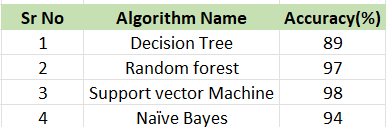

**As per the therotical and matematical prediction i found that SVM giving high accuracy .**

##Hyperparameter Tuning(Result)

In [ ]:

# Evaluate the model
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Initialize the SVM model
svm_model = SVC(random_state=101)

# Perform grid search
grid_search = GridSearchCV(svm_model, param_grid, refit=True, verbose=2)
grid_search.fit(x_train, y_train)

# Get the best parameters and estimator
print("Best Parameters:", grid_search.best_params_)
best_svm_model = grid_search.best_estimator_

# Make predictions on the test data
best_svm_predictions = best_svm_model.predict(x_test)
print("Best SVM Accuracy:", accuracy_score(y_test, best_svm_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_svm_predictions))
print("Classification Report:\n", classification_report(y_test, best_svm_predictions))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df=pd.read_csv("breast cancer.csv")
df
df.shape
df.info()
df.describe
df.isna().sum()

df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0}) # M-cancerous,B- non cancerous
x=df.drop(columns=['diagnosis',"id"])
y=df["diagnosis"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
#x_train
y

from sklearn.svm import SVC
model=SVC(kernel='linear',random_state=101)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("classification_report",classification_report(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print(f"accuracy{accuracy_score(y_test,y_pred)}")
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Initialize the SVM model
svm_model = SVC(random_state=101)

# Perform grid search
grid_search = GridSearchCV(svm_model, param_grid, refit=True, verbose=2)
grid_search.fit(x_train, y_train)

# Get the best parameters and estimator
print("Best Parameters:", grid_search.best_params_)
best_svm_model = grid_search.best_estimator_

# Make predictions on the test data
best_svm_predictions = best_svm_model.predict(x_test)

# Evaluate the model
print("Best SVM Accuracy:", accuracy_score(y_test, best_svm_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_svm_predictions))
print("Classification Report:\n", classification_report(y_test, best_svm_predictions))

#model saving
import joblib
joblib.dump(best_svm_model,"breast cancer.pkl")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

['breast cancer.pkl']